# Comparitive Analysis of Dimensionality Reduction Techniques

**Name:** Neil Cardoz and Nimit Prakash

**PRN:** 23070126079 and 23070126082

## **Index**
1. Load and preprocess the dataset
2. Apply dimensionality reduction techniques (PCA, LDA, t-SNE, MDS)
3. Visualize the reduced dimensions
4. Comparative Analysis
5. Compare classification accuracies
6. Conclusion

## What is Dimensionality Reduction ?

Dimensionality reduction is a technique used to simplify datasets by reducing the number of features (or variables) while retaining the most important information, making data easier to process, visualize, and analyzcs. It helps in:
- Reducing computational complexity
- Removing noise and redundant data
- Improving model performance and visualization (especially for high-dimensional data)

Certainly! Here’s a refined version of your content in Markdown format:

## Understanding Dimensionality Reduction Techniques

### 1. Principal Component Analysis (PCA)
- **Description**: PCA is a linear technique that identifies new orthogonal axes, known as principal components, which capture the maximum variance in the dataset.
- **Applications**: It is primarily utilized for feature extraction, data compression, and visualization.
- **Characteristics**: While PCA preserves the global structure of the data, it may compromise the interpretability of individual features.

### 2. Linear Discriminant Analysis (LDA)
- **Description**: LDA is a supervised method that determines the optimal feature space for class separation by maximizing the ratio of between-class variance to within-class variance.
- **Applications**: Unlike PCA, LDA is focused on class labels and is particularly effective for classification tasks.

### 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)
- **Description**: t-SNE is a non-linear technique designed to maintain local structure, primarily used for data visualization.
- **Mechanism**: It employs probability distributions and gradient descent to project high-dimensional data into 2D or 3D spaces.
- **Limitations**: While excellent for clustering, t-SNE does not effectively preserve global relationships within the data.

### 4. Multidimensional Scaling (MDS)
- **Description**: MDS arranges points in a lower-dimensional space while preserving pairwise distances from the original high-dimensional space.
- **Requirements**: This technique works best when a distance or similarity matrix is available.
- **Characteristics**: In contrast to t-SNE, MDS aims to retain the global structure of the data.

### 5. Singular Value Decomposition (SVD)
- **Description**: SVD is a matrix factorization technique used for dimensionality reduction, data compression, and noise reduction.
- **Mathematical Representation**: It decomposes a matrix  A into three smaller matrices:
  $$
  A = U \Sigma V^T
  $$

U: Left singular vectors (representing data in a new basis)

Σ: Singular values (indicating the importance of each component)

$V^T$: Right singular vectors (indicating principal directions of the data)




## Aim  
To implement and compare dimensionality reduction techniques (PCA, LDA, t-SNE, MDS) on a dataset and visualize their 2D/3D embeddings using subplots for effective analysis.

### About the Dataset

We will be using a **Heart Disease Dataset** for performing comparative analysis. This dataset includes demographic, clinical, and diagnostic features commonly associated with heart disease prediction.

### About the Dataset

We will be using a **Heart Disease Dataset** for performing comparative analysis. This dataset includes demographic, clinical, and diagnostic features commonly associated with heart disease prediction. The dataset contains the following 14 features:

| **Feature**          | **Description**                                                                                     | **Values**                                                                 |
|-----------------------|-----------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------|
| **age**              | Age of the patient.                                                                                | Integer.                                                                   |
| **sex**              | Gender of the patient.                                                                             | 0 = Female, 1 = Male.                                                      |
| **cp**               | Chest pain type.                                                                                   | 1 = Typical angina, 2 = Atypical angina, 3 = Non-anginal pain, 4 = Asymptomatic. |
| **trestbps**         | Resting blood pressure (in mm Hg).                                                                 | Integer or float.                                                          |
| **chol**             | Serum cholesterol level (in mg/dL).                                                                | Integer or float.                                                          |
| **fbs**              | Fasting blood sugar > 120 mg/dL.                                                                   | 0 = False, 1 = True.                                                       |
| **restecg**          | Resting electrocardiographic results.                                                              | 0 = Normal, 1 = Left ventricular hypertrophy, 2 = ST-T wave abnormality.   |
| **thalach**          | Maximum heart rate achieved.                                                                       | Integer or float.                                                          |
| **exang**            | Exercise-induced angina.                                                                           | 0 = No, 1 = Yes.                                                           |
| **oldpeak**          | ST depression induced by exercise relative to rest.                                                | Float value.                                                               |
| **slope**            | Slope of the peak exercise ST segment.                                                             | 0 = Upsloping, 1 = Flat, 2 = Downsloping.                                  |
| **ca**               | Number of major vessels (0–3) colored by fluoroscopy.                                              | Integer (0 to 3).                                                          |
| **thal**             | Thalassemia condition of the patient.                                                              | 3 = Normal, 6 = Fixed defect, 7 = Reversible defect.                       |
| **num (target)**     | Diagnosis of heart disease (angiographic disease status).                                           | 0 = No presence (<50% narrowing), 1 = Presence (>50% narrowing).           |

### Applications:
The dataset will be used to:
1. Apply dimensionality reduction techniques such as PCA, LDA, t-SNE, and MDS.
2. Visualize the transformed data in lower-dimensional spaces for better interpretability.
3. Compare the effectiveness of these techniques in preserving data structure and aiding in classification tasks.



### Applications:
The dataset will be used to:
1. Apply dimensionality reduction techniques such as PCA, LDA, t-SNE, and MDS.
2. Visualize the transformed data in lower-dimensional spaces for better interpretability.
3. Compare the effectiveness of these techniques in preserving data structure and aiding in classification tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE, MDS
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel

In [2]:
# Load Heart Disease dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
data = pd.read_csv(url, header=None, na_values="?")
data.columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", 
                "exang", "oldpeak", "slope", "ca", "thal", "num"]

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
data.shape

(303, 14)

In [5]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [6]:
# Handle missing values (fill with mean)
data.fillna(data.mean(), inplace=True)

In [7]:
data.shape

(303, 14)

In [8]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [9]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop(columns=['num'])) # num represents the presence and extent of heart disease
y = data['num']

In [10]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

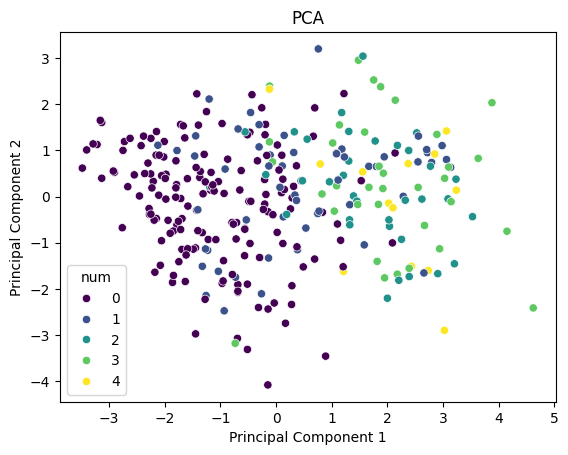

In [11]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis')
plt.title("PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [12]:
# LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

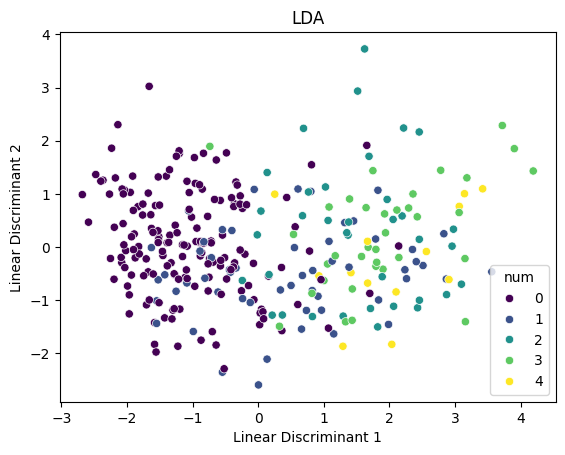

In [13]:
# LDA plot
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1] if X_lda.shape[1] > 1 else X_lda[:, 0], hue=y, palette='viridis')
plt.title("LDA")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2" if X_lda.shape[1] > 1 else "Linear Discriminant 1")
plt.show()

In [14]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Neil\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in

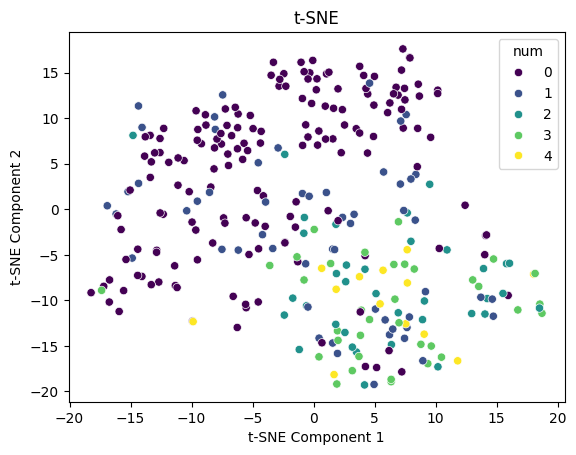

In [15]:
# t-SNE plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis')
plt.title("t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

In [16]:
# MDS
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

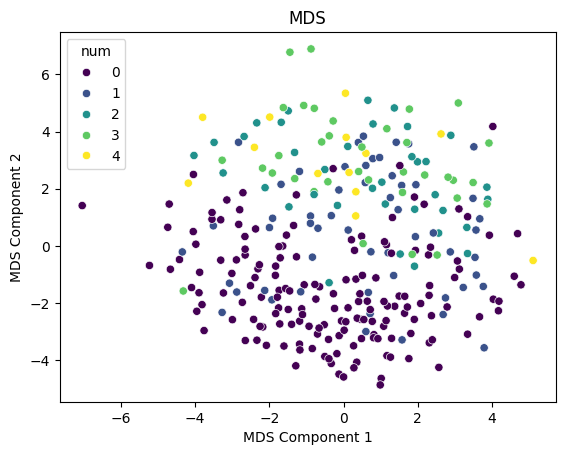

In [17]:
# MDS plot
sns.scatterplot(x=X_mds[:, 0], y=X_mds[:, 1], hue=y, palette='viridis')
plt.title("MDS")
plt.xlabel("MDS Component 1")
plt.ylabel("MDS Component 2")
plt.show()

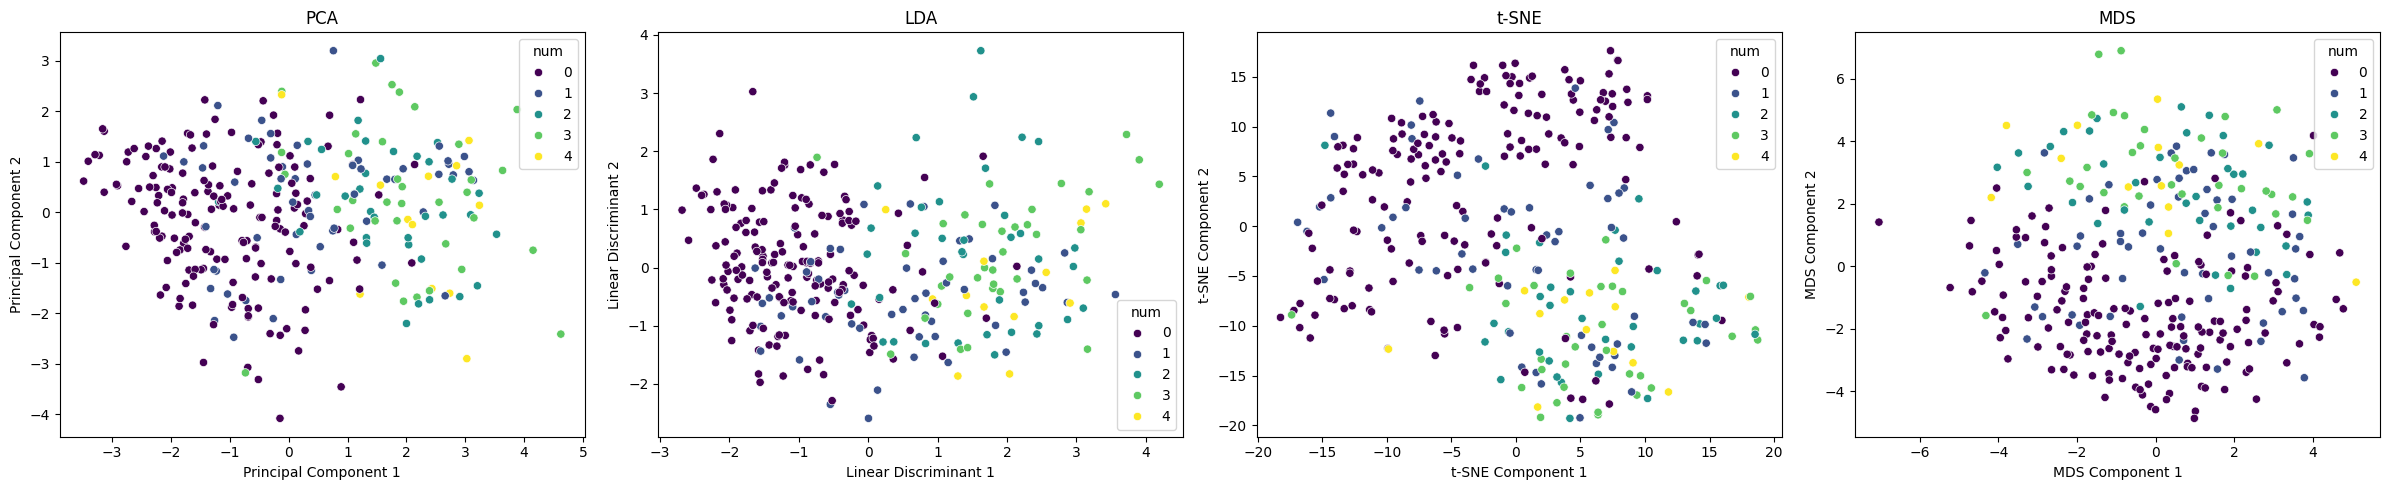

In [18]:
# Plotting subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# PCA plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', ax=axes[0])
axes[0].set_title("PCA")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# LDA plot
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1] if X_lda.shape[1] > 1 else X_lda[:, 0], hue=y, palette='viridis', ax=axes[1])
axes[1].set_title("LDA")
axes[1].set_xlabel("Linear Discriminant 1")
axes[1].set_ylabel("Linear Discriminant 2" if X_lda.shape[1] > 1 else "Linear Discriminant 1")

# t-SNE plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', ax=axes[2])
axes[2].set_title("t-SNE")
axes[2].set_xlabel("t-SNE Component 1")
axes[2].set_ylabel("t-SNE Component 2")

# MDS plot
sns.scatterplot(x=X_mds[:, 0], y=X_mds[:, 1], hue=y, palette='viridis', ax=axes[3])
axes[3].set_title("MDS")
axes[3].set_xlabel("MDS Component 1")
axes[3].set_ylabel("MDS Component 2")

plt.tight_layout()
plt.show()

# Comparitive Analysis

#### 1. PCA (Principal Component Analysis): 

**Observations in Plot:**
- The largest category (purple points) forms a somewhat cohesive cluster, mostly to the left, indicating that the first principal component captures some variation that separates that category from the rest.
- Other categories (greens, yellows, etc.) are scattered on the right side but show partial overlap with each other, meaning PCA is not separating them strongly in just two dimensions.
- Overall, PCA preserves global variance well, but does not necessarily maximize class separability.

**Interpretation:**
If the goal is purely to capture maximum variance in fewer dimensions, PCA is a good start. However, it may not produce the best visual separation among classes.


#### 2. LDA (Linear Discriminant Analysis)

**Observations in Your Plot:**
- You can see a more distinct linear separation for at least the largest category (purple) from the others, indicating LDA is actively pushing different categories apart.
- Some smaller clusters may still overlap, but overall, it tends to show clearer separation than PCA.

**Interpretation:**
LDA is typically better than PCA if the end goal is classification or if we want to highlight differences among labeled categories. It leverages label information, so it usually clusters categories more distinctly in the projected space.


#### 3. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Observations in Your Plot:**
- The data is split into clusters that are often quite compact. You might see certain categories forming tight blobs, while others partially overlap.
- t-SNE can produce visually striking clusters, but note that distances between clusters in t-SNE do not necessarily reflect true global distances.

**Interpretation:**
t-SNE is very popular for visual exploration of how data points might cluster locally. It can help identify interesting substructures or potential subclusters within a single label.


#### 4. MDS (Multidimensional Scaling)

**Observations in Your Plot:**
- We can typically see a more “spread out” distribution, sometimes with moderate separation between the largest category and the others, but it may not form distinct tight clusters like t-SNE.
- MDS attempts to preserve global pairwise relationships, so you may see that categories are somewhat separated but not always in neat clusters.


**Interpretation:**
MDS is best if you care about preserving how similar or dissimilar points are in general. It can reveal if one group is more distant from the others or if two groups are quite similar in the original space.

## Comparing classification accuracies

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Classification using KNN
knn = KNeighborsClassifier(n_neighbors=3)

In [20]:
from sklearn.preprocessing import LabelEncoder

# Extract features (all columns except "num")
X = data.drop(columns=["num"]).values  

# Extract labels (target variable "num")
y = data["num"].values  

# Convert "num" to binary classification (0 = No Disease, 1 = Has Disease)
y = (y > 0).astype(int) 

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
# PCA Classification
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)
knn.fit(X_train_pca, y_train_pca)
y_pred_pca = knn.predict(X_test_pca)
pca_acc = accuracy_score(y_test_pca, y_pred_pca)

# LDA Classification
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_lda, y, test_size=0.3, random_state=42)
knn.fit(X_train_lda, y_train_lda)
y_pred_lda = knn.predict(X_test_lda)
lda_acc = accuracy_score(y_test_lda, y_pred_lda)

# t-SNE Classification
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(X_tsne, y, test_size=0.3, random_state=42)
knn.fit(X_train_tsne, y_train_tsne)
y_pred_tsne = knn.predict(X_test_tsne)
tsne_acc = accuracy_score(y_test_tsne, y_pred_tsne)

# MDS Classification
X_train_mds, X_test_mds, y_train_mds, y_test_mds = train_test_split(X_mds, y, test_size=0.3, random_state=42)
knn.fit(X_train_mds, y_train_mds)
y_pred_mds = knn.predict(X_test_mds)
mds_acc = accuracy_score(y_test_mds, y_pred_mds)


# Print classification accuracies
print(f'PCA Classification Accuracy: {pca_acc:.2f}')
print(f'LDA Classification Accuracy: {lda_acc:.2f}')
print(f't-SNE Classification Accuracy: {tsne_acc:.2f}')
print(f'MDS Classification Accuracy: {mds_acc:.2f}')

PCA Classification Accuracy: 0.76
LDA Classification Accuracy: 0.87
t-SNE Classification Accuracy: 0.80
MDS Classification Accuracy: 0.80


# Final Conclusion

Based on the classification accuracy results:

1. LDA (0.87) achieved the highest accuracy, indicating that it is the most effective technique for classification in this dataset. This is expected, as LDA is designed to maximize class separability.
2. t-SNE (0.80) performed slightly better than PCA and MDS, showing that it preserves local structures well, though it is primarily used for visualization rather than classification.
3. PCA (0.76) and MDS (0.80) had the same accuracy, suggesting that while they help in dimensionality reduction, they may not be as effective as LDA for classification.
**Conclusion:**
LDA is the most suitable technique for classification in this dataset. t-SNE, PCA, and MDS are useful for visualization but do not perform as well for classification for this dataset